In [105]:
import os
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import xarray as xr

from oslofjord_sim.stuff import fill_nans_with_nearest, list_opendap_files, regrid_from_norkyst

In [106]:

PARAMETERS = ["temperature", "salinity", "u_eastward", "v_northward"]

### Data fetching
Process downloaded NorKyst data (ROMS model for the Norwegian coast).
This data will be used for the boundary conditions, which are set up as forcing.
Skip if you have it already.

In [107]:
DATA_DIR = Path("/home/eya/FjordSim_data/oslofjord/NorKyst2/")
# List all .nc files in the folder (non-recursive)
#files = [f.name for f in data_dir.glob("*.nc")]
#print(files)
def list_local_files():
    return [f.name for f in DATA_DIR.glob("*.nc")]


In [108]:
# names are like 20240101, so put an appropriate string to get specific files
month_string = "2020" #"202001"
#files = sorted([s for s in list_opendap_files() if month_string in s])
#urls = [os.path.join(OPENDAP_URL, x) for x in files]
#dss = [xr.open_dataset(url)[PARAMETERS] for url in urls]
files = sorted([name for name in list_local_files() if month_string in name])
paths = [DATA_DIR / name for name in files]
dss = [xr.open_dataset(path)[PARAMETERS] for path in paths]

In [109]:
ds = xr.combine_by_coords(dss, combine_attrs="override")  # downloading, takes a while

In [110]:
encoding = {var: {"zlib": True, "complevel": 5} for var in ds.data_vars}
ds.to_netcdf(
    os.path.join(Path.home(), "FjordSim_data", "oslofjord", f"NorKyst-800m_ZDEPTHS_avg_{month_string}.nc"),
    encoding=encoding,
)

In [111]:
del ds, dss, files, encoding, month_string
##del ds, dss, urls, files, encoding, month_string

### Regridding
Open the downloaded datasets and regrid them to the coordinates from a bathymetry file.

In [112]:
FILES = sorted(
    os.path.join(Path.home(), "FjordSim_data", "oslofjord", f)
    for f in os.listdir(os.path.join(Path.home(), "FjordSim_data", "oslofjord"))
    if f.startswith("NorKyst-800m_ZDEPTHS_avg_")
)

In [113]:
##ds_grid = xr.open_dataset(os.path.join(Path.home(), "FjordSim_data", "oslofjord", "bathymetry_105to232.nc"))
ds_grid = xr.open_dataset(os.path.join(Path.home(), "FjordSim_data", "oslofjord", "bathymetry_drammen1.nc"))

In [114]:
lat_diff = np.diff(ds_grid["lat"].values)[0]
lat_faces = np.zeros(shape=ds_grid["lat"].values.shape[0] + 1)
lat_faces[0] = ds_grid["lat"].values[0] - lat_diff / 2
lat_faces[1:] = ds_grid["lat"].values + lat_diff / 2

In [115]:
lon_diff = np.diff(ds_grid["lon"].values)[0]
lon_faces = np.zeros(shape=ds_grid["lon"].values.shape[0] + 1)
lon_faces[0] = ds_grid["lon"].values[0] - lon_diff / 2
lon_faces[1:] = ds_grid["lon"].values + lon_diff / 2

In [116]:
z_faces = ds_grid.z_faces.values
z_centers = [(z_faces[i] + z_faces[i + 1]) / 2 for i in range(len(z_faces) - 1)]
ds_out_c = xr.Dataset(
    {
        "lat": (["lat"], ds_grid["lat"].values, {"units": "degrees_north"}),
        "lon": (["lon"], ds_grid["lon"].values, {"units": "degrees_east"}),
    }
)
ds_out_u = xr.Dataset(
    {
        "lat": (["lat"], ds_grid["lat"].values, {"units": "degrees_north"}),
        "lon": (["lon"], lon_faces, {"units": "degrees_east"}),
    }
)
ds_out_v = xr.Dataset(
    {
        "lat": (["lat"], lat_faces, {"units": "degrees_north"}),
        "lon": (["lon"], ds_grid["lon"].values, {"units": "degrees_east"}),
    }
)

In [117]:
time_list = []
temp_list = []
salt_list = []
u_list = []
v_list = []

for file in FILES:
    ds_in = xr.open_dataset(file)
    #if '202010' in file: 
        # delete the last record in October, its time is 2022 somehow (and 1 missing time)
     #   ds_in = ds_in.isel(time=slice(0, -1))
    new_time = pd.date_range(start=ds_in.time[0].values, end=ds_in.time[-1].values, freq="D")
    ds_in = ds_in.reindex(time=new_time, method="ffill")

    #year = pd.to_datetime(ds_in.time[0].values).year
    #full_year_time = pd.date_range(start=f"{year}-01-01",end=f"{year}-12-31",freq="D")

    # Don't reuse regridders - create fresh ones for each file
    regridder_rho, regridder_u, regridder_v, np_time, np_temp, np_salt, np_u, np_v = regrid_from_norkyst(
        None, None, None, ds_in, ds_out_c, ds_out_u, ds_out_v, np.array(z_centers)
    )
    #regridder_rho, regridder_u, regridder_v, np_time, np_temp, np_salt, np_u, np_v = regrid_from_norkyst(
    #    regridder_rho, regridder_u, regridder_v, ds_in, ds_out_c, ds_out_u, ds_out_v, np.array(z_centers)
    #)
    time_list.append(np_time)
    temp_list.append(np_temp)
    salt_list.append(np_salt)
    u_list.append(np_u)
    v_list.append(np_v)
    print(f"File {file} processed.")

File /home/eya/FjordSim_data/oslofjord/NorKyst-800m_ZDEPTHS_avg_2020.nc processed.


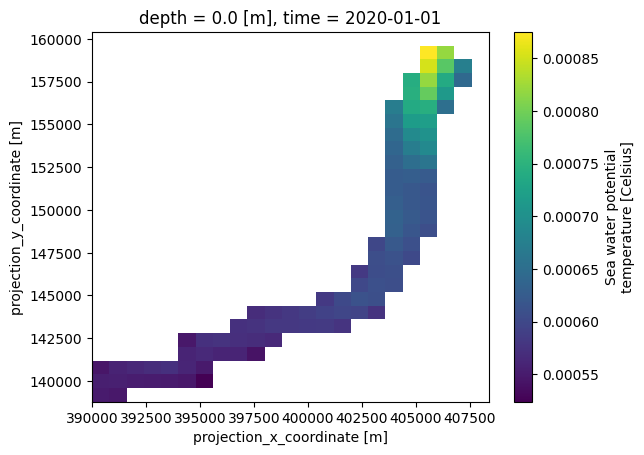

In [118]:
ds_in.temperature.isel(time=0, depth=0).plot()

In [119]:
ds_out_c

<xarray.Dataset> Size: 688B
Dimensions:  (lat: 67, lon: 19)
Coordinates:
  * lat      (lat) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * lon      (lon) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
Data variables:
    *empty*

In [120]:
np_time = np.concatenate(time_list, axis=0)
np_temp = np.concatenate(temp_list, axis=0).astype(np.float32)
np_salt = np.concatenate(salt_list, axis=0).astype(np.float32)
np_u = np.concatenate(u_list, axis=0).astype(np.float32)
np_v = np.concatenate(v_list, axis=0).astype(np.float32)

In [121]:
Tout_lambda = np.zeros_like(np_temp)
Sout_lambda = np.zeros_like(np_salt)
Uout_lambda = np.zeros_like(np_u)
Vout_lambda = np.zeros_like(np_v)

In [122]:
dsout = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], Tout_lambda),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], Sout_lambda),
        "u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        "u_lambda": (["time", "Nz", "Ny", "Nx_faces"], Uout_lambda),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], Vout_lambda),
    },
    coords={
        "time": np_time,
        "Nz": z_centers,
        "Nz_faces": z_faces,
        "Ny": ds_grid["lat"].values,
        "Ny_faces": lat_faces,
        "Nx": ds_grid["lon"].values,
        "Nx_faces": lon_faces,
    },
)

In [123]:
dsout

<xarray.Dataset> Size: 258MB
Dimensions:   (time: 366, Nz: 17, Ny: 67, Nx: 19, Nx_faces: 20, Ny_faces: 68,
               Nz_faces: 18)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz        (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -4.0 -2.5 -1.5 -0.5
  * Ny        (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx        (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
  * Nx_faces  (Nx_faces) float64 160B 10.22 10.24 10.25 ... 10.43 10.44 10.46
  * Ny_faces  (Ny_faces) float64 544B 59.58 59.59 59.59 ... 59.75 59.75 59.76
  * Nz_faces  (Nz_faces) float64 144B -115.0 -100.0 -90.0 ... -2.0 -1.0 0.0
Data variables:
    T         (time, Nz, Ny, Nx) float32 32MB nan nan nan nan ... nan nan nan
    T_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S         (time, Nz, Ny, Nx) float32 32MB nan nan nan nan ... nan nan nan
    S_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u         (time, Nz, Ny, Nx_faces) float32 33MB nan nan nan ... nan nan nan
    u_lambda  (time, Nz, Ny, Nx_faces) float32 33MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v         (time, Nz, Ny_faces, Nx) float32 32MB nan nan nan ... nan nan nan
    v_lambda  (time, Nz, Ny_faces, Nx) float32 32MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [124]:
z_level = -1

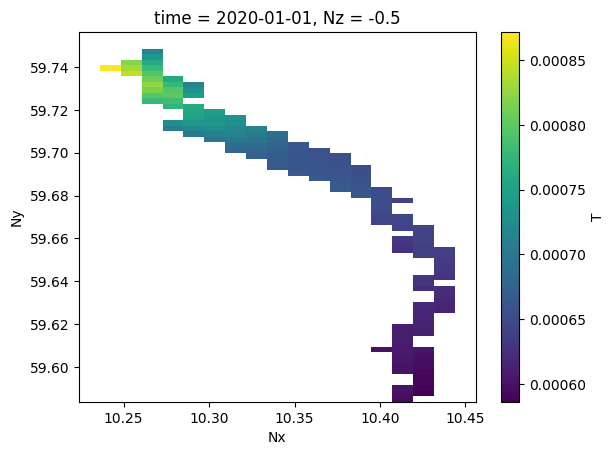

In [125]:
dsout.T.isel(time=0, Nz=z_level).plot()

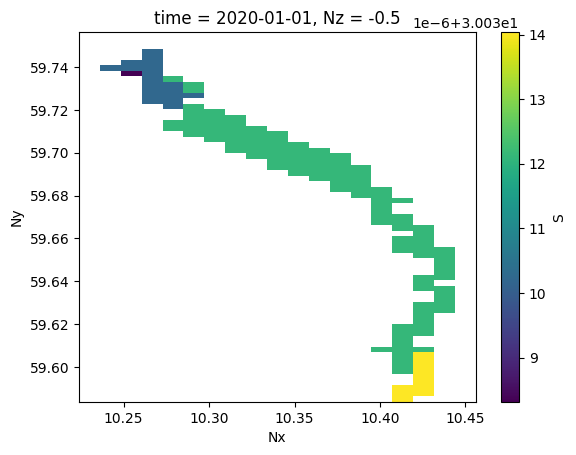

In [126]:
dsout.S.isel(time=0, Nz=z_level).plot()

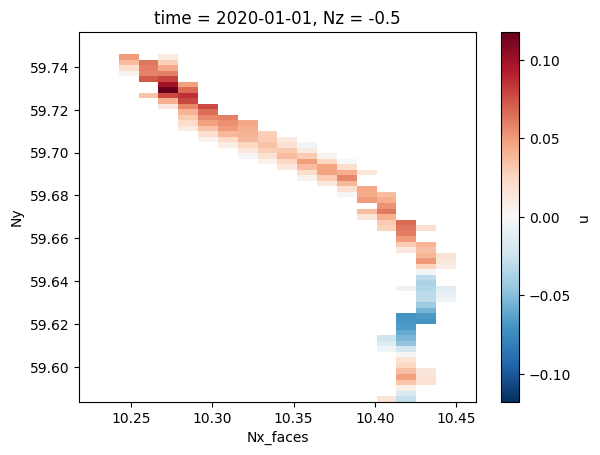

In [127]:
dsout.u.isel(time=0, Nz=z_level).plot()

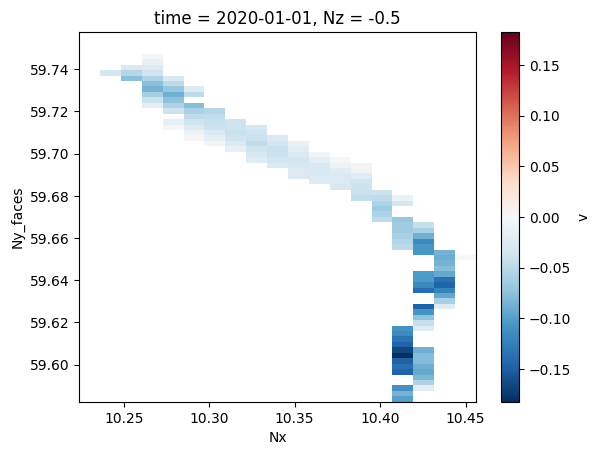

In [128]:
dsout.v.isel(time=0, Nz=z_level).plot()

### Prepare the forcing dataset
add Lambda values for boundaries, add rivers, etc.

In [129]:
ds = dsout.copy(deep=True)

In [130]:
np_z_centers = (ds_grid.z_faces.values[:-1] + ds_grid.z_faces.values[1:]) / 2
oy, ox, oz = (value for value in ds_grid.sizes.values())
np_mask = (np_z_centers > ds_grid.h.values[..., np.newaxis]).astype(int).transpose(2, 0, 1)

In [131]:
np_mask_u = np.zeros((oz - 1, oy, ox + 1))
np_mask_u[:, :, :-1] = np_mask
np_mask_u[:, :, 1:] = np.where(np_mask_u[:, :, 1:] == 0, np_mask, np_mask_u[:, :, 1:])

In [132]:
np_mask_v = np.zeros((oz - 1, oy + 1, ox))
np_mask_v[:, :-1, :] = np_mask
np_mask_v[:, 1:, :] = np.where(np_mask_v[:, 1:, :] == 0, np_mask, np_mask_v[:, 1:, :])

In [133]:
ds.T.values = fill_nans_with_nearest(ds.T) * np_mask
ds.S.values = fill_nans_with_nearest(ds.S) * np_mask
ds.u.values = fill_nans_with_nearest(ds.u) * np_mask_u
ds.v.values = fill_nans_with_nearest(ds.v) * np_mask_v

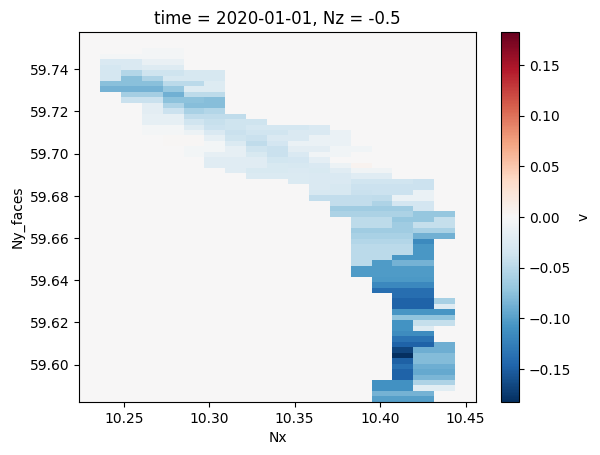

In [134]:
ds.v.isel(time=0, Nz=-1).plot()

There are some data gaps in the downloaded datasets

In [135]:
ds = ds.sortby("time")

In [136]:
ds

<xarray.Dataset> Size: 387MB
Dimensions:   (time: 366, Nz: 17, Ny: 67, Nx: 19, Nx_faces: 20, Ny_faces: 68,
               Nz_faces: 18)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz        (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -4.0 -2.5 -1.5 -0.5
  * Ny        (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx        (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
  * Nx_faces  (Nx_faces) float64 160B 10.22 10.24 10.25 ... 10.43 10.44 10.46
  * Ny_faces  (Ny_faces) float64 544B 59.58 59.59 59.59 ... 59.75 59.75 59.76
  * Nz_faces  (Nz_faces) float64 144B -115.0 -100.0 -90.0 ... -2.0 -1.0 0.0
Data variables:
    T         (time, Nz, Ny, Nx) float64 63MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    T_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S         (time, Nz, Ny, Nx) float64 63MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u         (time, Nz, Ny, Nx_faces) float64 67MB -0.0 -0.0 -0.0 ... 0.0 0.0
    u_lambda  (time, Nz, Ny, Nx_faces) float32 33MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    v         (time, Nz, Ny_faces, Nx) float64 64MB -0.0 -0.0 -0.0 ... -0.0 -0.0
    v_lambda  (time, Nz, Ny_faces, Nx) float32 32MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [137]:
new_time = pd.date_range(start=ds.time[0].values, end=ds.time[-1].values, freq="D")
new_time[~new_time.isin(ds.time.values)]  # this shows which dates are missing in the original data

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

In [138]:
new_time = pd.date_range(start=ds_in.time[0].values, end=ds_in.time[-1].values, freq="D")
if len(new_time) == 1:
    # For single timestep, ensure it's unique
    new_time = pd.DatetimeIndex([ds_in.time[0].values])
ds_in = ds_in.reindex(time=new_time, method="ffill")

In [139]:
#ds = ds.reindex(time=new_time, method="ffill")

Fill in lambdas for the sourthern boundary conditions.
Lambdas that -1 < lambda < 1 are relaxation rates.
Lambdas > 2 mean flux in x direction (west to east).
Lambdas < -1 mean flux in y direction (south to north).

In [140]:
southern_edge = 10  # use relaxation at 10 southernmost 'layers' at all depths
lambda_relaxation = 1 / (60 * 60 * 24)

In [141]:
ds["T_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["T_lambda"] = ds["T_lambda"].astype(np.float32)
ds["S_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask[:, :southern_edge, :]
ds["S_lambda"] = ds["S_lambda"].astype(np.float32)
ds["u_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask_u[:, :southern_edge, :]
ds["u_lambda"] = ds["u_lambda"].astype(np.float32)
ds["v_lambda"][:, :, :southern_edge, :] = (lambda_relaxation) * np_mask_v[:, :southern_edge, :]
ds["v_lambda"] = ds["v_lambda"].astype(np.float32)

In [142]:
ds["T"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["T"][:, :, :, :])
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["u"][:, :, :, :] = (np.where(np_mask_u == 0, np.nan, np_mask_u) * ds["u"][:, :, :, :])
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])

In [143]:
def fill_bgh_var(df, da, repeat=7):
    arr = df.values[:, 1:]
    arr = arr[:, ::-1]
    first_col = arr[:, [0]]
    extra_cols = np.repeat(first_col, repeat, axis=1)
    arr = np.hstack((extra_cols, arr))    # add bottom layers
    arr = np.vstack((arr, arr[[-1], :]))  # add the last day
    arr = arr[:, :, None, None]
    arr = np.tile(arr, (1, 1, da.shape[2], da.shape[3]))
    return xr.DataArray(arr, dims=da.dims, coords=da.coords, attrs=da.attrs).astype(np.float32)

In [144]:
NUT = xr.DataArray(np.zeros_like(ds.S.values),
                   dims=ds.S.dims,coords=ds.S.coords)
ds["NUT"] = NUT
NUT_lambda = xr.DataArray(np.zeros_like(ds.S_lambda.values),
                          dims=ds.S_lambda.dims,coords=ds.S_lambda.coords)
ds["NUT_lambda"] = NUT_lambda

DOM = xr.DataArray(np.zeros_like(ds.S.values),
                   dims=ds.S.dims,coords=ds.S.coords)
ds["DOM"] = DOM
DOM_lambda = xr.DataArray(np.zeros_like(ds.S_lambda.values),
                          dims=ds.S_lambda.dims,coords=ds.S_lambda.coords)
ds["DOM_lambda"] = DOM_lambda


POM = xr.DataArray(np.zeros_like(ds.S.values),
                   dims=ds.S.dims,coords=ds.S.coords)
ds["POM"] = POM
POM_lambda = xr.DataArray(np.zeros_like(ds.S_lambda.values),
                          dims=ds.S_lambda.dims,coords=ds.S_lambda.coords)
ds["POM_lambda"] = POM_lambda

P = xr.DataArray(np.zeros_like(ds.S.values),
                   dims=ds.S.dims,coords=ds.S.coords)
ds["P"] = P
P_lambda = xr.DataArray(np.zeros_like(ds.S_lambda.values),
                          dims=ds.S_lambda.dims,coords=ds.S_lambda.coords)
ds["P_lambda"] = P_lambda

#O₂ = xr.DataArray(np.zeros_like(ds.S.values),
#                   dims=ds.S.dims,coords=ds.S.coords)
#ds["O₂"] = O₂
#O₂_lambda = xr.DataArray(np.zeros_like(ds.S_lambda.values),
#                          dims=ds.S_lambda.dims,coords=ds.S_lambda.coords)
#ds["O₂_lambda"] = O₂_lambda

print(ds)

<xarray.Dataset> Size: 767MB
Dimensions:     (time: 366, Nz: 17, Ny: 67, Nx: 19, Nx_faces: 20, Ny_faces: 68,
                 Nz_faces: 18)
Coordinates:
  * time        (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz          (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -2.5 -1.5 -0.5
  * Ny          (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx          (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
  * Nx_faces    (Nx_faces) float64 160B 10.22 10.24 10.25 ... 10.43 10.44 10.46
  * Ny_faces    (Ny_faces) float64 544B 59.58 59.59 59.59 ... 59.75 59.75 59.76
  * Nz_faces    (Nz_faces) float64 144B -115.0 -100.0 -90.0 ... -2.0 -1.0 0.0
Data variables: (12/16)
    T           (time, Nz, Ny, Nx) float64 63MB nan nan nan nan ... nan nan nan
    T_lambda    (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S           (time, Nz, Ny, Nx) float64 63MB nan nan nan nan ... nan nan nan
    S_lambda    (time, Nz, N

In [145]:
#df_NUT = pd.DataFrame(10.0 * np.ones((30, 20)))  # df_NUT = pd.DataFrame(10.0 * np.ones((30, 20))) 
#df_NUT = pd.read_csv(os.path.join(Path.home(), "FjordSim_data", "oslofjord", "Sea_boundary", "NUT.txt"), sep="\t")
#ds["NUT"] = fill_bgh_var(df_NUT, ds["NUT"])

Add rivers


In [ ]:
def get_river(file_name):
    df_Barumsbassenget_DOM = pd.read_csv(
        os.path.join(Path.home(), "FjordSim_data", "oslofjord", "Rivers",file_name), sep="\t"
    )
    df = df_Barumsbassenget_DOM
    arr = np.abs(df.values[:, 3]) # we read information for the substance discharge (umol/s) from the 4th column instead of concentration in column 3
    arr = np.append(arr, arr[-1])
    arr = np.repeat(arr[:, None], 2, axis=1)
    return arr

river_lambda = 1 / (60 * 60) / 1200  # 1 per hour ! 

In [147]:
# Drammenselva
y, x = 62, 1 ###94, 3 
# y,x - coordinates of the river mouth in the grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["S"].values[:, -2:, y, x] = 0
ds["S_lambda"].values[:, -2:, y, x] = river_lambda
ds["v"].values[:, -2:, y + 1, x] = -0.5  # negative flux means 'to the south'
ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])

ds["NUT"].values[:, -2:, y, x] =  get_river("river_N3_n_from_18_year_2020.txt")
ds["NUT_lambda"].values[:, -2:, y, x] = river_lambda
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])

ds["DOM"].values[:, -2:, y, x] =  get_river("river_N3_n_from_18_year_2020.txt")
ds["DOM_lambda"].values[:, -2:, y, x] = river_lambda 
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])

#ds["POM"].values[:, -2:, y, x] =  get_river("river_N3_n_from_18_year_2020.txt")
#ds["POM_lambda"].values[:, -2:, y, x] = river_lambda
#ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])


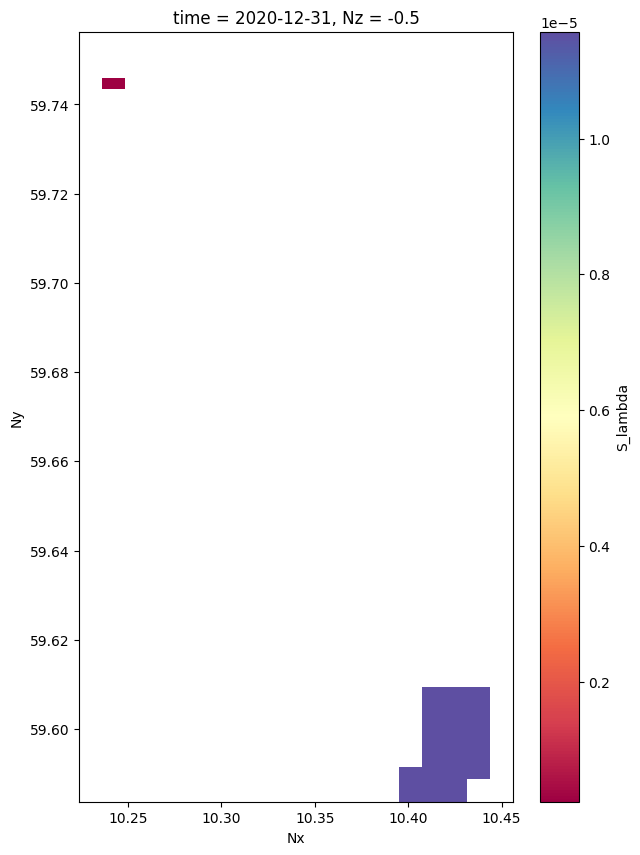

In [148]:
ds.S_lambda.isel(time=-1, Nz=-1).where(lambda x: x != 0).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

In [149]:
# Lierelva
y, x = 63, 4 #63, 5 ###95, 8   
# y,x - coordinates of the river mouth in the large Oslo fjord grid
# u_lambda = 2 for horizontal (W-E)  =-2 for vertical (N-S)
# u =-0.5 directed from N to S
ds["S"].values[:, -2:, y, x] = 0
ds["S_lambda"].values[:, -2:, y, x] = river_lambda
ds["v"].values[:, -2:, y + 1, x] = -0.5  # negative flux means 'to the south'
ds["v_lambda"].values[:, -2:, y + 1, x] = -2  # this lambda means flux in 'y' direction
ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])
ds["NUT"].values[:, -2:, y, x] =  get_river("river_N3_n_from_17_year_2020.txt")
ds["NUT_lambda"].values[:, -2:, y, x] = river_lambda
ds["NUT"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["NUT"][:, :, :, :])
ds["DOM"].values[:, -2:, y, x] =  get_river("river_N3_n_from_17_year_2020.txt")
ds["DOM_lambda"].values[:, -2:, y, x] = river_lambda
ds["DOM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["DOM"][:, :, :, :])
#ds["POM"].values[:, -2:, y, x] =  get_river("river_N3_n_from_17_year_2020.txt")
#ds["POM_lambda"].values[:, -2:, y, x] = river_lambda 
#ds["POM"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["POM"][:, :, :, :])


In [150]:
#ds.S.isel(time=-1, Nz=-1, Ny=slice(180, 190), Nx=slice(5, 15)).plot(cmap=mpl.colormaps.get_cmap("Spectral"))

In [151]:
# Barumsbassenget
#y, x = 218, 42
#ds["S"].values[:, -2:, y, x] = 0
#ds["S_lambda"].values[:, -2:, y, x] = 1 / (60 * 60)
#ds["u"].values[:, -2:, y, x] = 0.5  # to the east
#ds["u_lambda"].values[:, -2:, y, x] = 2  # x direction
#ds["S"][:, :, :, :] = (np.where(np_mask == 0, np.nan, np_mask) * ds["S"][:, :, :, :])
#ds["v"][:, :, :, :] = (np.where(np_mask_v == 0, np.nan, np_mask_v) * ds["v"][:, :, :, :])

In [152]:
#ds.S.isel(time=-1, Nz=-1, Ny=slice(215, 225), Nx=slice(40, 50)).plot(cmap=mpl.colormaps.get_cmap("Spectral"))

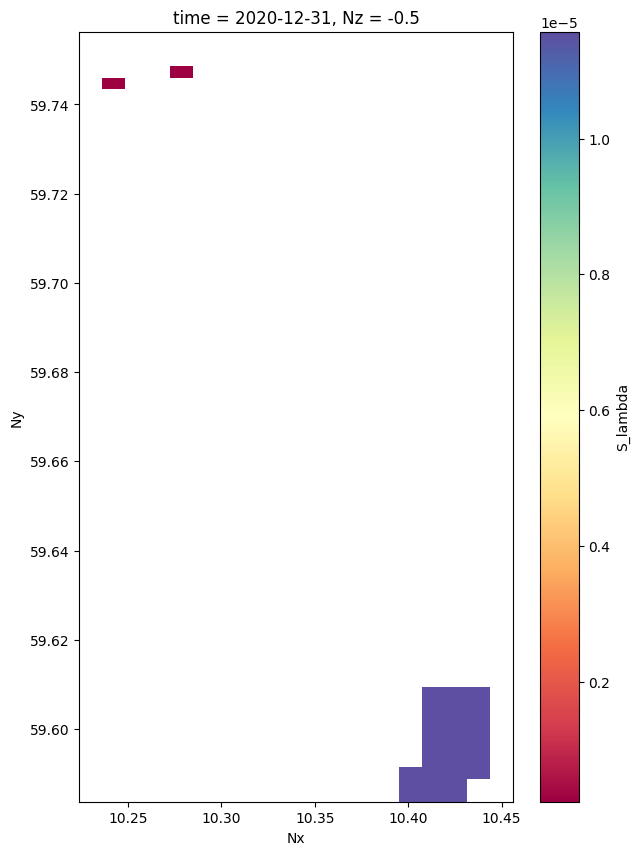

In [153]:
ds.S_lambda.isel(time=-1, Nz=-1).where(lambda x: x != 0).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

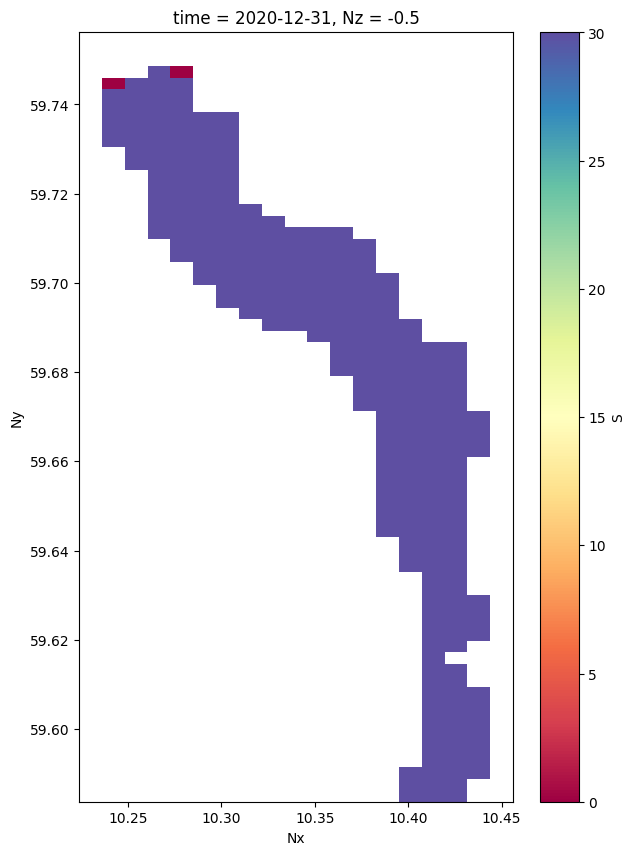

In [154]:
ds.S.isel(time=-1, Nz=-1).plot(cmap=mpl.colormaps.get_cmap("Spectral"), figsize=(7, 10))

In [155]:
ds

<xarray.Dataset> Size: 767MB
Dimensions:     (time: 366, Nz: 17, Ny: 67, Nx: 19, Nx_faces: 20, Ny_faces: 68,
                 Nz_faces: 18)
Coordinates:
  * time        (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * Nz          (Nz) float64 136B -107.5 -95.0 -85.0 -75.0 ... -2.5 -1.5 -0.5
  * Ny          (Ny) float64 536B 59.59 59.59 59.59 59.59 ... 59.75 59.75 59.76
  * Nx          (Nx) float64 152B 10.23 10.24 10.25 10.27 ... 10.43 10.44 10.45
  * Nx_faces    (Nx_faces) float64 160B 10.22 10.24 10.25 ... 10.43 10.44 10.46
  * Ny_faces    (Ny_faces) float64 544B 59.58 59.59 59.59 ... 59.75 59.75 59.76
  * Nz_faces    (Nz_faces) float64 144B -115.0 -100.0 -90.0 ... -2.0 -1.0 0.0
Data variables: (12/16)
    T           (time, Nz, Ny, Nx) float64 63MB nan nan nan nan ... nan nan nan
    T_lambda    (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S           (time, Nz, Ny, Nx) float64 63MB nan nan nan nan ... nan nan nan
    S_lambda    (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    u           (time, Nz, Ny, Nx_faces) float64 67MB nan nan nan ... nan nan
    u_lambda    (time, Nz, Ny, Nx_faces) float32 33MB 0.0 0.0 0.0 ... 0.0 0.0
    ...          ...
    DOM         (time, Nz, Ny, Nx) float64 63MB nan nan nan nan ... nan nan nan
    DOM_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    POM         (time, Nz, Ny, Nx) float64 63MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    POM_lambda  (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    P           (time, Nz, Ny, Nx) float64 63MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    P_lambda    (time, Nz, Ny, Nx) float32 32MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

Save

In [156]:
encoding = {var: {"zlib": True, "complevel": 5} for var in ds.data_vars}
ds.to_netcdf(
    os.path.join(Path.home(), "FjordSim_data", "oslofjord", "forcing_drammen.nc"), #"forcing_105to232.nc"),
    encoding=encoding,
)